# 2.Attention Distillation

This document implements the second step of the system. Before running this code, please execute the Jupyter notebook of the first step. If skipped, only the native VAE provided by Stable Diffusion will be invoked rather than the VAE fine‑tuned in the first step, which will adversely affect the visual quality of the final output images.

/home/s5714322/masterclass/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


当前使用设备: cuda
正在加载自定义水墨 VAE...
正在加载 Stable Diffusion 管道...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'pipeline_sd.ADPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


模型加载与修复完成！


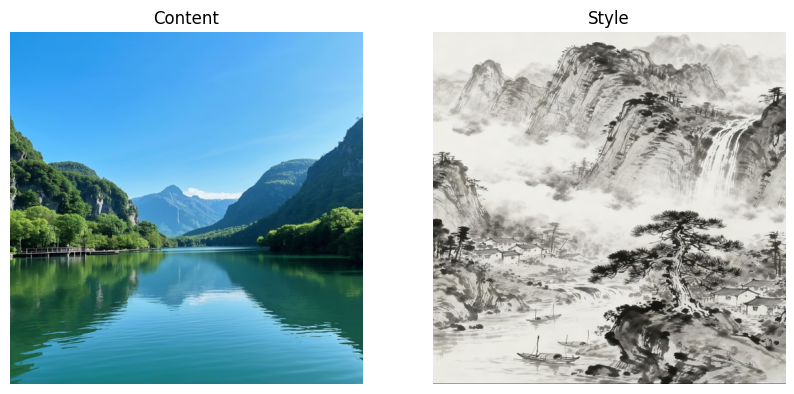

正在执行注意力蒸馏优化 (大约需要 1-2 分钟)...


/home/s5714322/masterclass/lib64/python3.9/site-packages/diffusers/pipelines/pipeline_utils.py:2186: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `ADPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


Total self attention layers of Unet:  16
Self attention layers for AD:  [10, 11, 12, 13, 14, 15]


Optimize: 100%|███████████████████████████████████████| 51/51 [25:55<00:00, 30.50s/it, iter=199, loss=1.78, time=1]


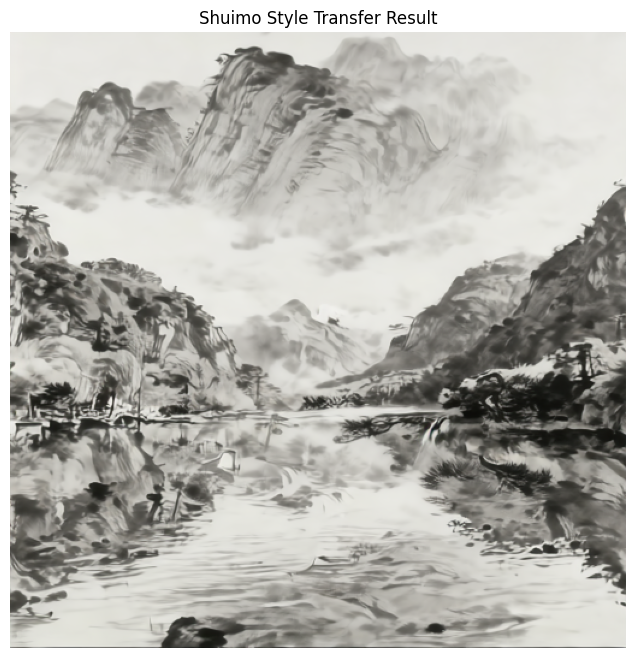

迁移成功！结果已保存为: shuimo_final_result.png


In [2]:
import torch
import os
import matplotlib.pyplot as plt
from accelerate import Accelerator
from diffusers import AutoencoderKL
from torchvision.utils import save_image

# Ensure these files exist in the current directory: pipeline_sd.py, utils.py, losses.py
from pipeline_sd import ADPipeline
from utils import Controller, load_image

# =================  1. Basic Configuration =================
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "runwayml/stable-diffusion-v1-5"
# Path to custom ink‑wash VAE
vae_path = "./trained_vae_notebook/trained_vae_shuimo" 
# Image paths
content_path = "shanshui.png"   # Input content photograph
style_path = "shuimo.png"     # 训Original ink‑wash painting used for VAE training

print(f"Current device: {device}")

# =========== 2. Load Models and Fix Missing Attributes ===========
# Load VAE
if os.path.exists(vae_path):
    print("Loading custom ink‑wash VAE...")
    vae = AutoencoderKL.from_pretrained(vae_path).to(device, dtype=torch.float32)
else:
    print("Custom VAE not found, loading original VAE...")
    vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device, dtype=torch.float32)

# Load Pipeline
print("Loading Stable Diffusion pipeline...")
pipe = ADPipeline.from_pretrained(
    model_id, 
    vae=vae, 
    torch_dtype=torch.float32,
    safety_checker=None 
).to(device)


pipe.classifier = pipe.unet 
pipe.accelerator = Accelerator(mixed_precision="no")
pipe.vae_scale_factor = 8 # default value for SD 1.5 is 8
pipe.freeze()

print("Model loading and attribute fixing completed!")

# =========== 3. Prepare Images and Controller ===========
# Load images and resize to 512x512
content_image = load_image(content_path, size=(512, 512))
style_image = load_image(style_path, size=(512, 512))

# Extract self‑attention features from the last 6 layers 
controller = Controller(self_layers=(10, 16)) 

# # Preview input images (fix: use .cpu() to resolve display error)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(content_image[0].cpu().permute(1, 2, 0))
ax[0].set_title("Content")
ax[0].axis('off')
ax[1].imshow(style_image[0].cpu().permute(1, 2, 0))
ax[1].set_title("Style")
ax[1].axis('off')
plt.show()

# ================= 4. Run Attention Distillation Optimization =================
print("Running attention distillation optimization...")

# optimization pipeline
result = pipe.optimize(
    style_image=style_image,
    content_image=content_image,
    controller=controller,
    lr=0.05,
    iters=200,        # Number of optimization iterations
    weight=0.25,      # Content weight: higher values preserve original content; lower values produce more stylized outputs
    num_inference_steps=50,
    width=512,
    height=512
)

# ================= 5. Visualize and Save Output =================
plt.figure(figsize=(8, 8))
plt.imshow(result[0].cpu().permute(1, 2, 0))
plt.title("Shuimo Style Transfer Result")
plt.axis('off')
plt.show()

# Save output image
output_name = "shuimo_final_result.png"
save_image(result[0].cpu(), output_name)
print(f"Style transfer finished! Result saved as: {output_name}")